<a href="https://colab.research.google.com/github/brucnsilva/topicos-de-big-data-em-phyton-pub/blob/main/codigo%20certo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import pandas as pd
from google.colab import files

In [15]:
print("Selecione o arquivo BaseMunicipioMensal (1).csv:")
uploaded = files.upload()

Selecione o arquivo BaseMunicipioMensal (1).csv:


Saving BaseMunicipioMensal (1).csv to BaseMunicipioMensal (1) (2).csv


In [16]:
df = pd.read_csv('BaseMunicipioMensal (1).csv', sep=';', encoding='latin-1')

In [21]:
colunas_desejadas = [
    'fmun',
    'ano',
    'mes',
    'regiao',
    'roubo_veiculo',
    'furto_veiculos',
    'trafico_drogas',
    'recuperacao_veiculos'
]

In [22]:
df_filtrado = df[colunas_desejadas]

In [24]:
print("\nPlanilha_filtrada_base_municipal (1)")
display(df_filtrado.head())


Planilha_filtrada_base_municipal (1)


,fmun,ano,mes,regiao,roubo_veiculo,furto_veiculos,trafico_drogas,recuperacao_veiculos
0,Angra dos Reis,2014,1,Interior,8,18,12,9
1,Aperibé,2014,1,Interior,0,0,0,0
2,Araruama,2014,1,Interior,9,16,4,4
3,Areal,2014,1,Interior,0,0,0,0
4,Armação dos Búzios,2014,1,Interior,2,9,10,2


In [25]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

# 1. Preparação dos Dados
df = pd.read_csv('planilha_filtrada_base_municipal (1).csv', sep=';')
df['total_veiculos'] = df['roubo_veiculo'] + df['furto_veiculos']

# 2. Agrupamento por Ano
df_anual = df.groupby('ano')['total_veiculos'].sum().reset_index()

X = df_anual[['ano']].values
y = df_anual['total_veiculos'].values

# 3. Treinamento do Modelo
modelo = LinearRegression()
modelo.fit(X, y)

# 4. Exibição dos Resultados
print(f"Equação da Reta: y = {modelo.intercept_:.2f} + ({modelo.coef_[0]:.2f})")

Equação da Reta: y = 5635494.14 + (-2766.86)


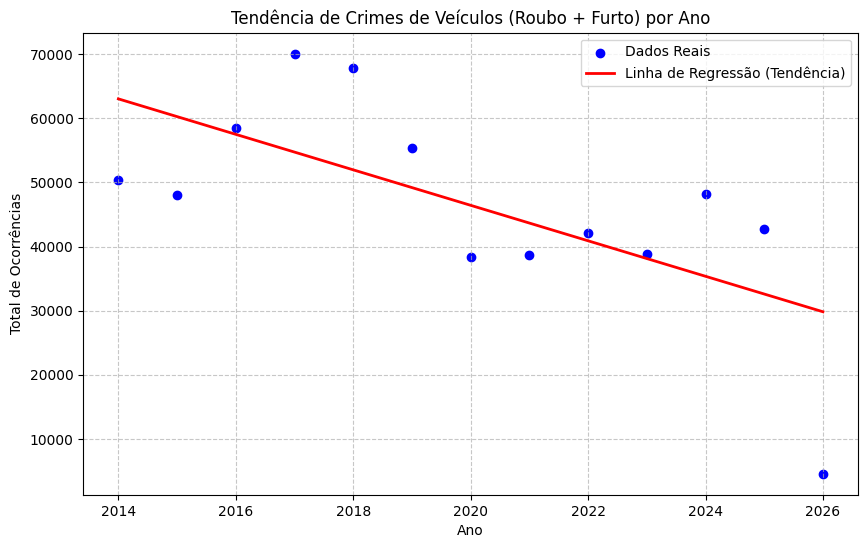

In [26]:
import matplotlib.pyplot as plt

# 1. Agrupar os dados para o gráfico
df_grafico = df.groupby('ano')['total_veiculos'].sum().reset_index()

# 2. Configurar o gráfico
plt.figure(figsize=(10, 6))
plt.scatter(df_grafico['ano'], df_grafico['total_veiculos'], color='blue', label='Dados Reais')

# 3. Adicionar a linha de regressão
previsoes = modelo.predict(X)
plt.plot(df_grafico['ano'], previsoes, color='red', linewidth=2, label='Linha de Regressão (Tendência)')

# 4. final
plt.title('Tendência de Crimes de Veículos (Roubo + Furto) por Ano')
plt.xlabel('Ano')
plt.ylabel('Total de Ocorrências')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

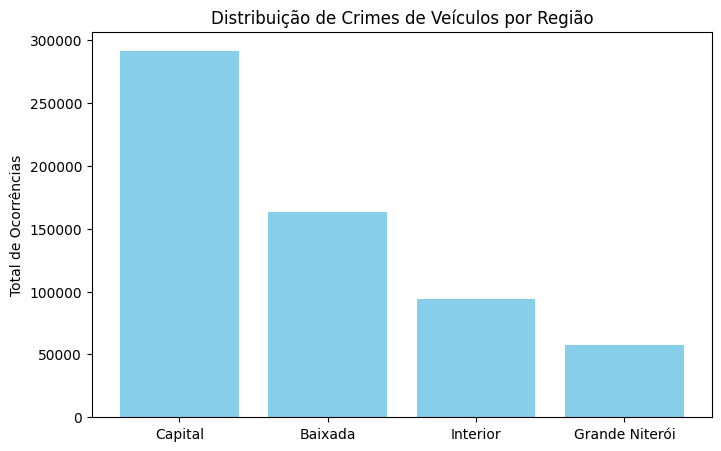

In [27]:
regioes = ['Capital', 'Baixada', 'Interior', 'Grande Niterói']
valores = [291684, 163452, 93985, 57320]

plt.figure(figsize=(8, 5))
plt.bar(regioes, valores, color='skyblue')
plt.title('Distribuição de Crimes de Veículos por Região')
plt.ylabel('Total de Ocorrências')
plt.show()